In [1]:
print("Iniciando notebook")

Iniciando notebook


In [ ]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import sqlite3
caminho_base = Path.cwd().parent
db_path = caminho_base / "db_lite" / "meu_banco_de_dados.db"

print(f"Buscando dados no banco: {db_path}")

conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM pedidos_reembolso", conn)
conn.close()

df

Buscando arquivo em: /home/pichau/Gabriel/ml_postech/build/raw/dados_reembolso_hipoteticos.csv


,dt_pedidoreembolso,dt_pagamentocentralunimed,dt_indeferimentoreembolso,nr_contrato,cd_empresacontrato,nm_empresa,nr_beneficiario,nm_beneficiario,nm_grupoempresa,nm_tipocobranca,...,nr_digitoagencia,nr_contacorrente,nr_digitocontacorrente,cd_usuarioatualizacao,nm_usuarioatualizacao,nm_emailatualizacao,nr_pedidoautorizacao,cd_prestadorexecutante,nm_prestadorexecutante,fl_pendenciamento
0,2025-06-18,NaN,NaN,CONTR-2772,721,Gamma Servicos,123461202,Beneficiario Exemplo 0,Grupo Corporativo Nacional,Custo Operacional,...,1,87720,0,SISTEMA,Robo de Integracao,contato@empresa.com.br,450700,EXEC-347,Clinica Executante 0,N
1,2025-08-04,NaN,NaN,CONTR-5079,492,Gamma Servicos,123479780,Beneficiario Exemplo 1,Grupo Corporativo Nacional,Pre-pagamento,...,1,53924,0,SISTEMA,Robo de Integracao,contato@empresa.com.br,145256,EXEC-883,Clinica Executante 1,N
2,2025-06-01,NaN,2025-06-09,CONTR-4007,260,Gamma Servicos,123468502,Beneficiario Exemplo 2,Grupo Corporativo Nacional,Pre-pagamento,...,1,48314,0,SISTEMA,Robo de Integracao,contato@empresa.com.br,711027,EXEC-240,Clinica Executante 2,N
3,2025-03-15,NaN,NaN,CONTR-3096,311,Beta Tech S.A.,123429050,Beneficiario Exemplo 3,Grupo Corporativo Nacional,Custo Operacional,...,1,60038,0,SISTEMA,Robo de Integracao,contato@empresa.com.br,502845,EXEC-254,Clinica Executante 3,N
4,2025-05-23,NaN,2025-06-03,CONTR-6198,721,Gamma Servicos,123449471,Beneficiario Exemplo 4,Grupo Corporativo Nacional,Pre-pagamento,...,1,31612,0,SISTEMA,Robo de Integracao,contato@empresa.com.br,144692,EXEC-219,Clinica Executante 4,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2025-02-01,NaN,NaN,CONTR-3665,518,Gamma Servicos,123455608,Beneficiario Exemplo 95,Grupo Corporativo Nacional,Pre-pagamento,...,1,16089,0,SISTEMA,Robo de Integracao,contato@empresa.com.br,633421,EXEC-640,Clinica Executante 95,N
96,2025-04-30,NaN,NaN,CONTR-2271,809,Gamma Servicos,123458387,Beneficiario Exemplo 96,Grupo Corporativo Nacional,Pre-pagamento,...,1,35718,0,SISTEMA,Robo de Integracao,contato@empresa.com.br,258679,EXEC-923,Clinica Executante 96,N
97,2025-06-05,2025-06-12,NaN,CONTR-1800,201,Beta Tech S.A.,123432631,Beneficiario Exemplo 97,Grupo Corporativo Nacional,Custo Operacional,...,1,76543,0,SISTEMA,Robo de Integracao,contato@empresa.com.br,536032,EXEC-967,Clinica Executante 97,N
98,2025-01-24,NaN,2025-02-08,CONTR-4818,480,Empresa Alfa Ltda,123432380,Beneficiario Exemplo 98,Grupo Corporativo Nacional,Custo Operacional,...,1,95016,0,SISTEMA,Robo de Integracao,contato@empresa.com.br,754172,EXEC-370,Clinica Executante 98,N


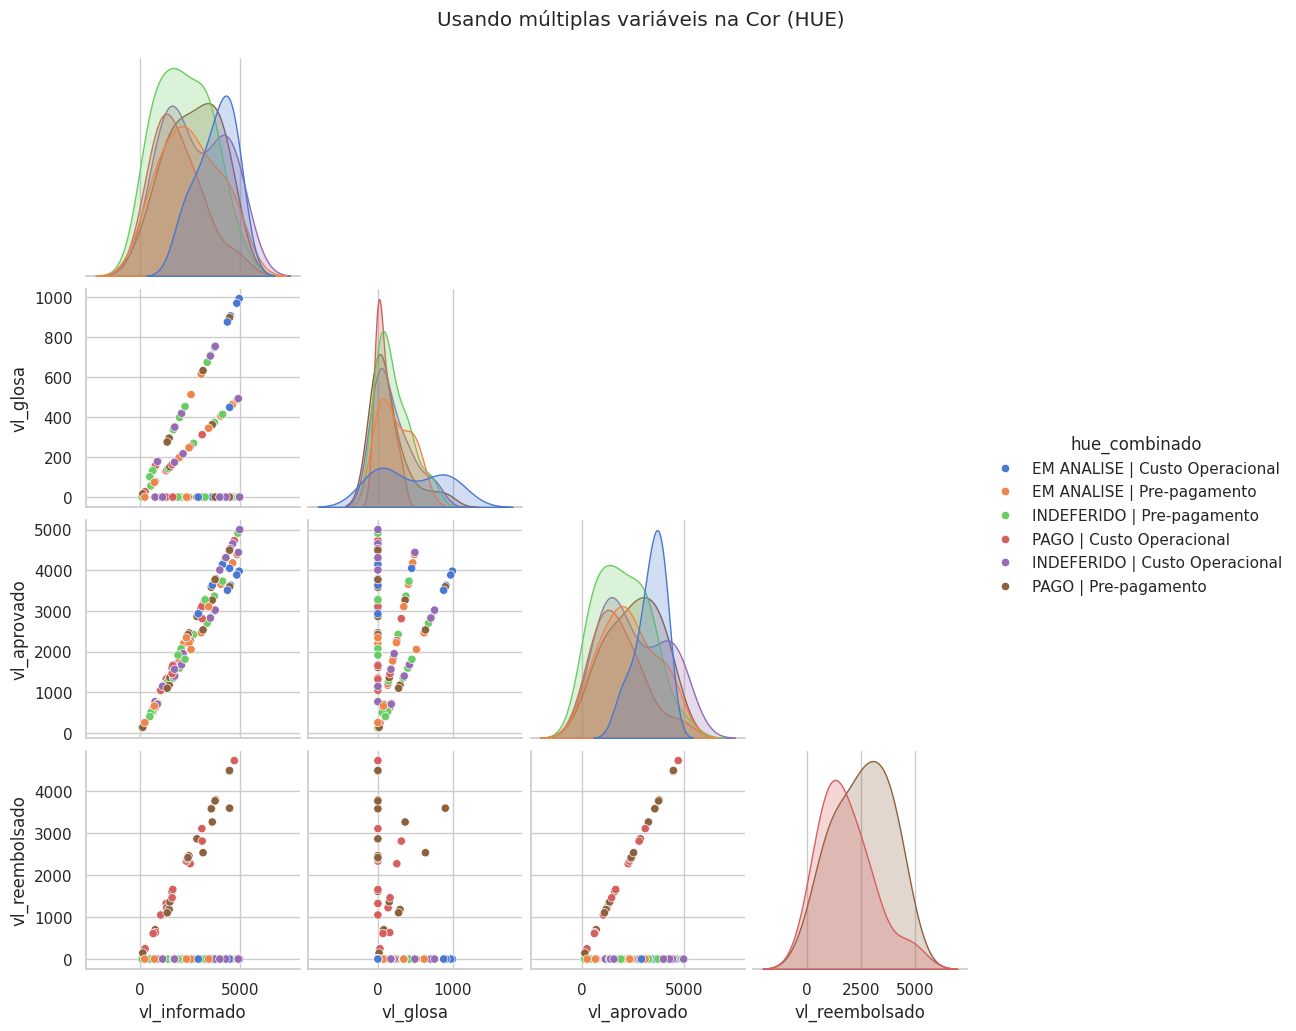

In [9]:
colunas_analise = ['vl_informado', 'vl_aprovado', 'vl_reembolsado', 'nm_situacaoreembolso']

# 1. Juntar as duas colunas com um separadorzinho no meio
df['hue_combinado'] = df['nm_situacaoreembolso'] + " | " + df['nm_tipocobranca']

# 2. Adicionar o "hue_combinado" nas nossas colunas_analise (senão o pairplot não acha ele)
colunas_para_pairplot = colunas_analise + ['hue_combinado']
colunas_para_pairplot.remove('nm_situacaoreembolso') # (Remove a antiga, já que tá no combinado)

# 3. Rodar o pairplot usando ele
grafico = sns.pairplot(
    data=df[colunas_para_pairplot], 
    hue='hue_combinado', 
    diag_kind='kde',
    corner=True
)
grafico.fig.suptitle('Usando múltiplas variáveis na Cor (HUE)', y=1.03)
plt.show()

1. Correlações Diretas e Comportamento Linear
vl_informado vs. vl_aprovado: Existe uma correlação linear fortíssima. Isso indica que, para a maioria dos casos, o valor aprovado segue proporcionalmente o valor informado, sugerindo que as regras de auditoria mantêm uma consistência previsível sobre o montante inicial.

vl_aprovado vs. vl_reembolsado: Note que os pontos se concentram em uma linha diagonal perfeita para as categorias PAGO. Isso confirma que o valor efetivamente reembolsado é, em regra, exatamente o valor que foi aprovado após as glosas.

2. O Papel da Glosa (Gargalo de Valor)
Distribuição de vl_glosa: O gráfico de densidade (KDE) no topo da segunda coluna mostra que a maioria das glosas é de baixo valor (próximo de zero). No entanto, há caudas longas para a direita, indicando casos excepcionais onde o valor glosado é alto.

Impacto no Fluxo: No gráfico vl_glosa vs vl_aprovado, observamos uma dispersão vertical. Isso mostra que altos valores aprovados podem ocorrer tanto com glosas baixas quanto altas, mas há uma concentração onde, se a glosa aumenta muito, o valor aprovado tende a ser menor (especialmente para os casos de "Custo Operacional").

3. Insights por Categoria (HUE)
PAGO | Custo Operacional vs. Pre-pagamento: A categoria de Custo Operacional (Vermelho) parece ter uma densidade maior em valores mais altos de reembolso comparado ao Pre-pagamento (Marrom), sugerindo que os tickets médios de reembolso operacional são mais elevados.

INDEFERIDO: Os pontos verdes e roxos (Indeferidos) aparecem com vl_aprovado e vl_reembolsado zerados ou muito baixos, independentemente do vl_informado. Isso valida visualmente que o processo de indeferimento está bloqueando o fluxo financeiro corretamente no sistema.

EM ANÁLISE: Os pontos azuis e laranjas estão sobrepostos a valores significativos de vl_informado. Isso representa o passivo financeiro latente: valores que já entraram no sistema mas ainda não transicionaram para o status de pago ou indeferido.

4. Anomalias e Outliers
Existem alguns pontos isolados no gráfico de vl_reembolsado vs vl_glosa. Casos onde há alta glosa e, ainda assim, alto reembolso merecem uma auditoria mais detalhada, pois podem indicar procedimentos complexos ou erros de lançamento onde o valor informado era desproporcionalmente alto.

Sugestões Práticas:
Foco na Glosa: Como a maioria das glosas é baixa, automatizar a aprovação de processos com baixo risco de glosa pode acelerar o tempo médio de pagamento (SLA).

Monitoramento de Pre-pagamento: Esta categoria apresenta uma dispersão menor, sugerindo um comportamento mais controlado ou tabelado do que o Custo Operacional.

### Resumo das Relações Financeiras
| Relação | Tendência | Insight |
| :--- | :--- | :--- |
| **Informado x Aprovado** | Linear Positiva | Baixa variação nas regras de auditoria. |
| **Aprovado x Reembolsado** | Identidade (1:1) | Processo de liquidação financeira íntegro. |
| **Glosa x Reembolsado** | Dispersão Variável | Glosas não são impeditivas para tickets altos. |

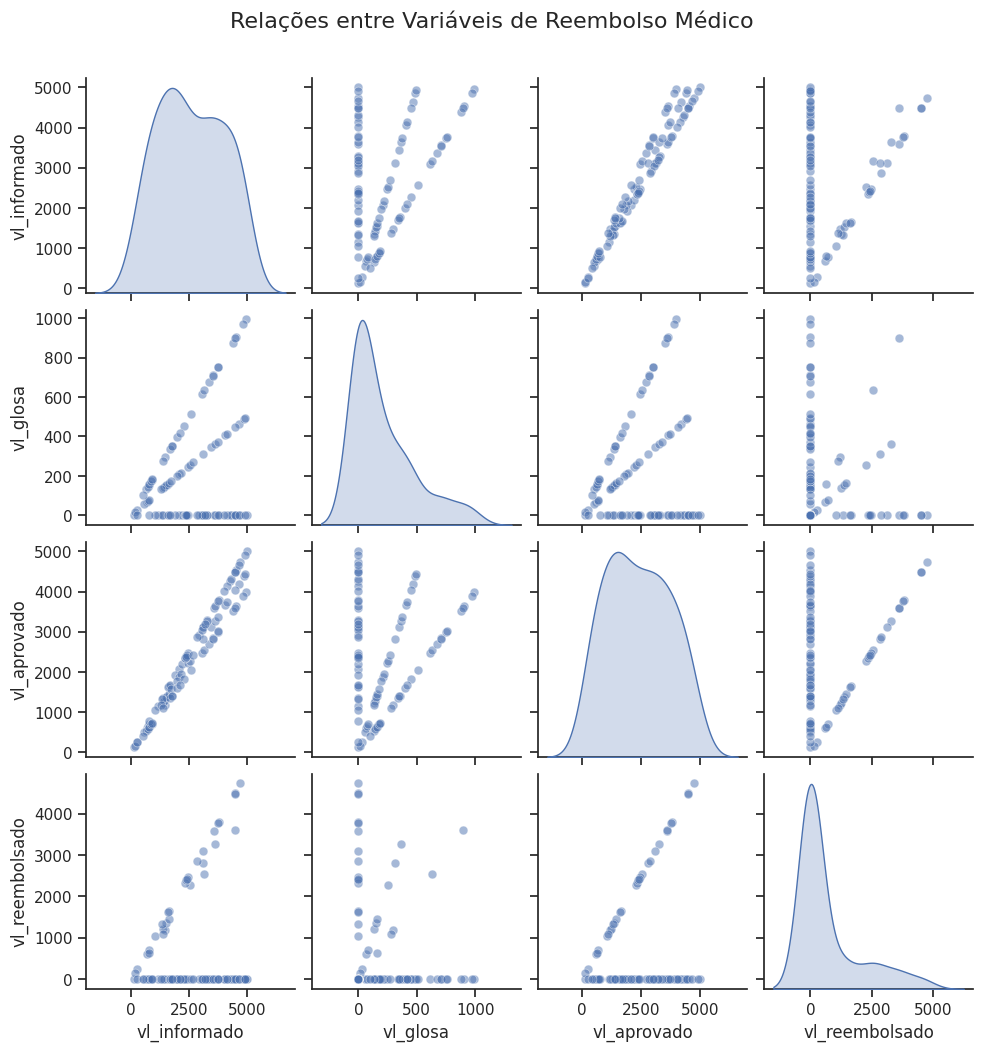

In [ ]:

cols_pairplot = [
    'vl_informado',
    'vl_glosa',
    'vl_aprovado',
    'vl_reembolsado'
]
pdf_sample = df[cols_pairplot].sample(frac=1.0, random_state=42)

pdf_sample = pdf_sample.dropna()

sns.set_theme(style="ticks")
g = sns.pairplot(
    pdf_sample, 
    diag_kind="kde", 
    plot_kws={'alpha': 0.5, 's': 40}  # 'alpha' = Transparência, 's' = Tamanho do ponto (aumentei levemente para 40 para ver melhor)
)

g.fig.suptitle("Relações entre Variáveis de Reembolso Médico", y=1.05, fontsize=16)
plt.show()


*Análise de Relações: Reembolso Médico (Visão Geral)
Este pairplot revela a mecânica financeira do fluxo de reembolso, destacando como o valor solicitado se transforma no valor pago após a aplicação de glosas.

1. Estrutura de Fluxo e Funil Financeiro
Conversão Direta (vl_informado vs. vl_aprovado): Observamos três linhas de tendência principais no gráfico vl_informado vs vl_aprovado.

A linha superior indica aprovação total.

As linhas inferiores indicam faixas de glosa recorrentes (provavelmente itens com coparticipação fixa ou glosas administrativas padronizadas).

Consistência de Saída (vl_aprovado vs. vl_reembolsado): A relação é quase 1:1. Isso indica que, uma vez que o valor passa pela auditoria e é aprovado, não há perdas adicionais significativos até o pagamento efetivo.

2. Padrões de Glosa (vl_glosa)
Comportamento Binário: No gráfico vl_glosa vs vl_informado, nota-se uma concentração massiva no eixo zero (muitos itens sem glosa) e uma dispersão que acompanha o aumento do valor informado.

Glosas de Teto: Existe uma linha vertical clara em vl_glosa (perto de 0-200), sugerindo que a grande massa de ajustes financeiros ocorre em valores pequenos, possivelmente taxas administrativas ou materiais de baixo custo.

Impacto Inverso: No gráfico vl_glosa vs vl_reembolsado, quanto maior a glosa, maior a dispersão dos pontos, mas o volume de pontos diminui drasticamente. Glosas acima de 500 são raras e impactam severamente o valor final.

3. Distribuição de Densidade (KDE)
vl_informado: Apresenta uma distribuição bimodal ou "achatada" no topo, indicando que o volume de pedidos é bem distribuído entre procedimentos de baixo valor (até 2500) e médio valor (4000).

vl_reembolsado: A densidade é maior próximo de zero, o que é comum em seguros saúde (muitos atendimentos de baixo custo, como consultas e exames simples, e poucos eventos de alta complexidade).

4. Identificação de Anomalias
No gráfico vl_glosa vs vl_reembolsado, há um ponto isolado (outlier) com glosa próxima de 1000 e reembolso próximo de 3500.

Insight: Casos onde a glosa é muito alta, mas o reembolso final também é alto, geralmente representam internações ou cirurgias complexas onde o valor glosado, embora alto nominalmente, é pequeno percentualmente em relação ao total.

### Tabela de Correlação Visual
| Par de Variáveis | Força da Relação | Observação |
| :--- | :---: | :--- |
| **Informado ➔ Aprovado** | Muito Alta | Indica previsibilidade do processo de auditoria. |
| **Glosa ➔ Aprovado** | Inversa / Dispersa | Glosas altas "empurram" o valor aprovado para baixo. |
| **Aprovado ➔ Reembolsado** | Total | Fidelidade absoluta entre o cálculo de auditoria e o depósito. |

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import pandas as pd

# 1. Expandindo nossas Variáveis Preditivas (X) e nosso Alvo (y)
colunas_preditoras = ['cd_procedimento', 'vl_informado', 'qt_informado', 'cd_tipoproduto']
alvo = 'vl_glosa'

# 2. Separando "O Passado/Decidido" vs "O Futuro/Em Análise"
df_historico = df[df['nm_situacaoreembolso'].isin(['PAGO', 'INDEFERIDO'])].copy()
df_futuro_analise = df[df['nm_situacaoreembolso'] == 'EM ANALISE'].copy()

print(f"Tamanho da Base Histórica para Treinar: {len(df_historico)} pedidos")
print(f"Tamanho da Base EM ANALISE para Prever: {len(df_futuro_analise)} pedidos\n")

X_historico = df_historico[colunas_preditoras].copy()
y_historico = df_historico[alvo]

X_historico = pd.get_dummies(X_historico, columns=['cd_procedimento'])

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_historico, y_historico, test_size=0.2, random_state=42
)

modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_treino, y_treino)

mae = mean_absolute_error(y_teste, modelo.predict(X_teste))
print(f"Desempenho no Histórico (O quão bem ele está lembrando) -> MAE: R$ {mae:.2f}")

# Preparando a base que queremos adivinhar o futuro:
X_futuro = df_futuro_analise[colunas_preditoras].copy()
X_futuro = pd.get_dummies(X_futuro, columns=['cd_procedimento'])

X_futuro = X_futuro.reindex(columns=X_historico.columns, fill_value=0)


df_futuro_analise.loc[:, 'PREVISAO_GLOSA_PELO_IA'] = modelo.predict(X_futuro)

df_futuro_analise.loc[:, 'vl_previsao'] = modelo.predict(X_futuro).round(2)

print("\n--- PREVIEW DA FILA 'EM ANÁLISE' COM O JULGAMENTO DA NOSSA IA ---")
display(df_futuro_analise[['nm_beneficiario', 'nm_situacaoreembolso', 'cd_procedimento', 'vl_informado', 'vl_previsao']].head(10))

Tamanho da Base Histórica para Treinar: 72 pedidos
Tamanho da Base EM ANALISE para Prever: 28 pedidos

Desempenho no Histórico (O quão bem ele está lembrando) -> MAE: R$ 142.42

--- PREVIEW DA FILA 'EM ANÁLISE' COM O JULGAMENTO DA NOSSA IA ---


,nm_beneficiario,nm_situacaoreembolso,cd_procedimento,vl_informado,vl_previsao
0,Beneficiario Exemplo 0,EM ANALISE,4030188,4972.31,79.89
1,Beneficiario Exemplo 1,EM ANALISE,4030348,1307.34,58.89
3,Beneficiario Exemplo 3,EM ANALISE,4030826,2080.00,238.42
5,Beneficiario Exemplo 5,EM ANALISE,4030423,3288.34,58.81
7,Beneficiario Exemplo 7,EM ANALISE,4030215,4855.58,75.17
10,Beneficiario Exemplo 10,EM ANALISE,4030714,4272.96,55.50
12,Beneficiario Exemplo 12,EM ANALISE,4030803,4538.82,36.02
13,Beneficiario Exemplo 13,EM ANALISE,4030811,4062.14,65.60
15,Beneficiario Exemplo 15,EM ANALISE,4030754,3751.94,90.69
18,Beneficiario Exemplo 18,EM ANALISE,4030750,2200.45,208.53


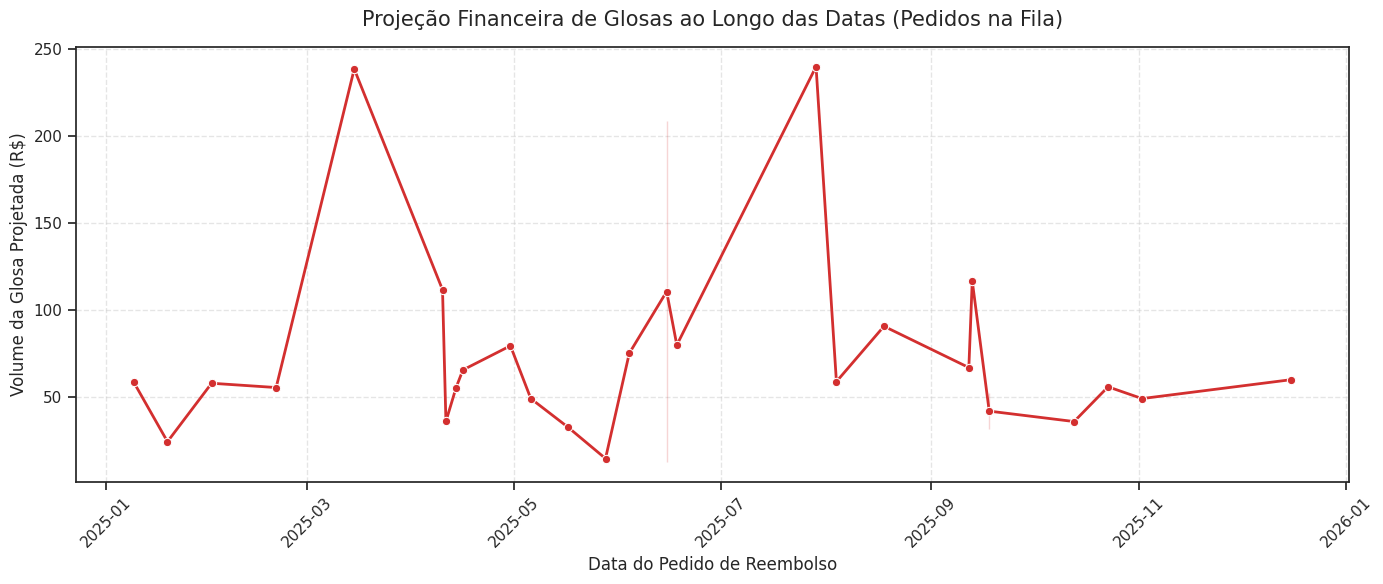

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_futuro_analise['dt_pedidoreembolso'] = pd.to_datetime(df_futuro_analise['dt_pedidoreembolso'])

df_grafico = df_futuro_analise.sort_values(by='dt_pedidoreembolso')

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df_grafico, 
    x='dt_pedidoreembolso',
    y='vl_previsao',
    marker='o',
    color='#D32F2F',
    linewidth=2
)

# Acabamentos do Gráfico
plt.title('Projeção Financeira de Glosas ao Longo das Datas (Pedidos na Fila)', fontsize=15, pad=15)
plt.xlabel('Data do Pedido de Reembolso', fontsize=12)
plt.ylabel('Volume da Glosa Projetada (R$)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()